In [29]:
import numpy as np

In [30]:
import joblib

X_train = joblib.load("../data/X_train_raw.joblib")
X_test = joblib.load("../data/X_test_raw.joblib")

y_train = joblib.load("../data/y_train.joblib")
y_test = joblib.load("../data/y_test.joblib")

In [31]:
print(type(X_train))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_validate, StratifiedKFold

In [33]:
numerical_columns = [
    "no_of_dependents",
    " income_annum",
    " loan_amount",
    " loan_term",
    " cibil_score",
    " residential_assets_value",
    " commercial_assets_value",
    " luxury_assets_value",
    " bank_asset_value",
    " total_assets",
    " loan_to_income_ratio",
    " asset_to_loan_ratio",
    " asset_to_income_ratio"
]

categorical_columns = [
    " education",
    " self_employed"
]

In [34]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [35]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [36]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [47]:
y_train = y_train.map({
    "Rejected": 0,
    "Approved": 1
})

y_test = y_test.map({
    "Rejected": 0,
    "Approved": 1
})

# model

In [48]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", logistic_model)
])

In [49]:
# it will make the crt weightage in all foldes(for cross validation , now we will send this to cv=skf)

In [50]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# logestic regression train on the C base value "  no happer tunning is done yet"

In [51]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=True
)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(3415, 15)


In [64]:
import pandas as pd

In [65]:
acc = pd.DataFrame(cv_results)

In [70]:
acc = acc.drop(["fit_time", "score_time"], axis=1)

In [71]:
acc

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.900439,0.913250,0.914153,0.928028,0.927059,0.932941,0.920561,0.930478,0.964742,0.969291
1,0.906296,0.913982,0.926714,0.932153,0.922353,0.929412,0.924528,0.930781,0.963602,0.969520
2,0.929722,0.905564,0.949881,0.921637,0.936471,0.927059,0.943128,0.924340,0.971236,0.967735
3,0.910688,0.915081,0.927230,0.930246,0.929412,0.933529,0.928320,0.931885,0.967570,0.968806
4,0.903367,0.910688,0.914550,0.927230,0.931765,0.929412,0.923077,0.928320,0.970397,0.968141


In [57]:
print("Accuracy :", cv_results["test_accuracy"])
print("Precision:", cv_results["test_precision"])
print("Recall   :", cv_results["test_recall"])
print("F1       :", cv_results["test_f1"])
print("ROC-AUC  :", cv_results["test_roc_auc"])

Accuracy : [0.90043924 0.90629575 0.92972182 0.91068814 0.9033675 ]
Precision: [0.91415313 0.92671395 0.94988067 0.92723005 0.91454965]
Recall   : [0.92705882 0.92235294 0.93647059 0.92941176 0.93176471]
F1       : [0.92056075 0.9245283  0.94312796 0.92831962 0.92307692]
ROC-AUC  : [0.96474236 0.96360237 0.97123575 0.96756954 0.97039672]


In [58]:

print("Mean Accuracy :", cv_results["test_accuracy"].mean())
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall   :", cv_results["test_recall"].mean())
print("Mean F1       :", cv_results["test_f1"].mean())
print("Mean ROC-AUC  :", cv_results["test_roc_auc"].mean())

Mean Accuracy : 0.9101024890190337
Mean Precision: 0.9265054898053828
Mean Recall   : 0.9294117647058824
Mean F1       : 0.9279227117368747
Mean ROC-AUC  : 0.9675093479252166


In [59]:
print("Accuracy STD :", cv_results["test_accuracy"].std())
print("Precision STD:", cv_results["test_precision"].std())
print("Recall STD   :", cv_results["test_recall"].std())
print("F1 STD       :", cv_results["test_f1"].std())
print("ROC-AUC STD  :", cv_results["test_roc_auc"].std())

Accuracy STD : 0.010377771681797562
Precision STD: 0.012980679200768442
Recall STD   : 0.004705882352941193
F1 STD       : 0.008006989177773581
ROC-AUC STD  : 0.0030049051071211674


In [60]:
print(
    "Mean Train Accuracy:",
    cv_results["train_accuracy"].mean()
)

print(
    "Mean Validation Accuracy:",
    cv_results["test_accuracy"].mean()
)

Mean Train Accuracy: 0.9117130307467057
Mean Validation Accuracy: 0.9101024890190337


In [ ]:
# Hyppertunning of the C 

In [72]:
C_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

In [80]:


param_grid = {
    "model__C": C_values
}

In [81]:
from sklearn.model_selection import GridSearchCV

In [82]:
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

In [83]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [84]:
print("Best C:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best C: {'model__C': 0.1}
Best CV ROC-AUC: 0.9675275877792977


In [85]:
results = pd.DataFrame(grid_search.cv_results_)

results[
    [
        "param_model__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_model__C,mean_test_score,std_test_score,rank_test_score
2,0.100,0.967528,0.003038,1
3,1.000,0.967509,0.003005,2
4,10.000,0.967383,0.002824,3
1,0.010,0.967376,0.002680,4
5,100.000,0.967354,0.002761,5
6,1000.000,0.967347,0.002757,6
0,0.001,0.966743,0.002325,7


#   finaly test on the test Data

In [86]:
best_model = grid_search.best_estimator_

In [87]:
y_pred = best_model.predict(X_test)

In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall   :", recall_score(y_test, y_pred))
print("Test F1       :", f1_score(y_test, y_pred))

y_prob = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC   :", roc_auc_score(y_test, y_prob))

Test Accuracy : 0.9192037470725996
Test Precision: 0.9215328467153284
Test Recall   : 0.9510357815442562
Test F1       : 0.9360518999073216
Test ROC-AUC   : 0.9750339624401648


# Confusion Matrix

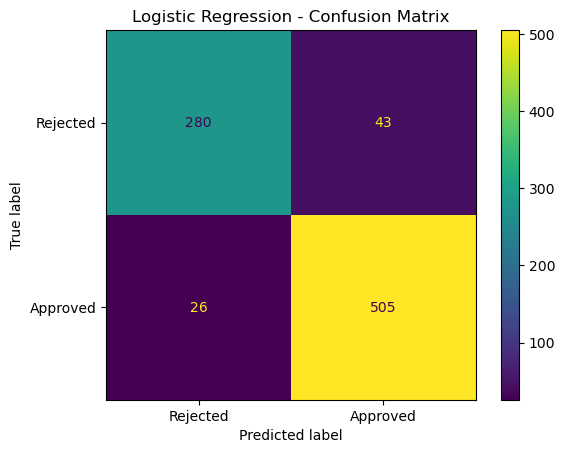

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Rejected", "Approved"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [91]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Rejected", "Approved"]
    )
)

              precision    recall  f1-score   support

    Rejected       0.92      0.87      0.89       323
    Approved       0.92      0.95      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854



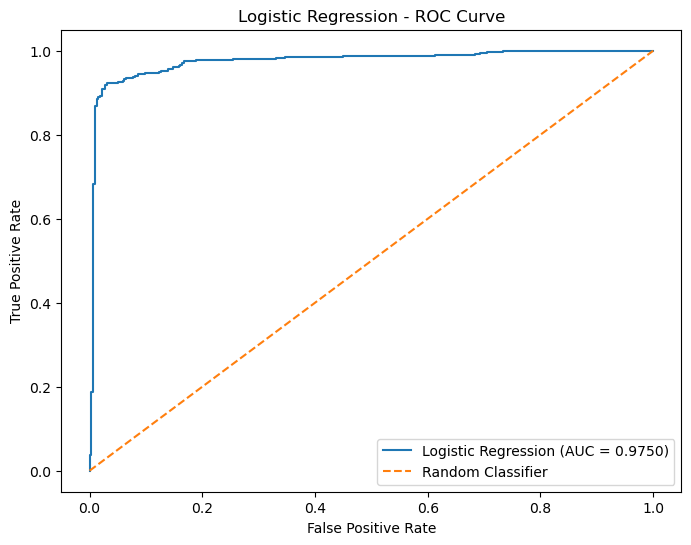

In [92]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.show()

In [ ]:
#  Roc we want to do this 